In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from skimage.feature import hog

# TensorFlow / Keras untuk Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [35]:
# Inisialisasi Haar Cascade Classifier bawaan OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def preprocess_pipeline(image_path, target_size=(128, 128)):
    """
    Fungsi ini mencakup Tahap 3.1, 3.2, dan 3.3 dari rancangan pipeline.
    """
    # Membaca citra
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Konversi ke Grayscale khusus untuk proses Haar Cascade
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3.1 Deteksi Wajah
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    # Jika tidak ada wajah, lewati citra ini
    if len(faces) == 0:
        return None 
        
    # Asumsikan kita mengambil wajah pertama yang terdeteksi
    x, y, w, h = faces[0]
    
    # 3.1 Pemotongan Citra (Cropping) pada citra berwarna
    face_roi_color = img[y:y+h, x:x+w]
    
    # 3.3 Peningkatan Mutu Citra (Enhancement) menggunakan CLAHE
    # Konversi ke ruang warna LAB agar CLAHE hanya memengaruhi intensitas (Lightness)
    lab = cv2.cvtColor(face_roi_color, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    
    # Gabungkan kembali dan konversi ke RGB
    limg = cv2.merge((cl, a, b))
    enhanced_face = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    
    # 3.2 Praproses Data: Penyeragaman Ukuran (Resize)
    resized_face = cv2.resize(enhanced_face, target_size)
    
    # 3.2 Praproses Data: Normalisasi Intensitas Piksel (0-1)
    normalized_face = resized_face / 255.0
    
    return normalized_face

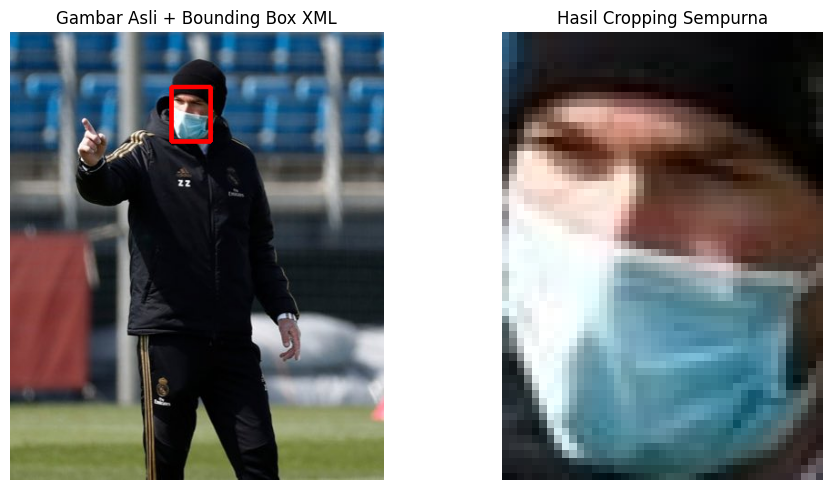

In [34]:
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os

# Path ke gambar dan XML-nya
img_path = r'D:\Games\Code\Semester 6\PCD\Project\full_dataset\1260207081694494720_0.jpg'
xml_path = r'D:\Games\Code\Semester 6\PCD\Project\annotations\1260207081694494720_0.xml'

# Pastikan file ada
if os.path.exists(img_path) and os.path.exists(xml_path):
    # Baca gambar
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Matplotlib butuh format RGB
    
    # Baca XML untuk dapatkan koordinat
    tree = ET.parse(xml_path)
    root = tree.getroot()
    bndbox = root.find('.//bndbox')
    
    if bndbox is not None:
        xmin = int(float(bndbox.find('xmin').text))
        ymin = int(float(bndbox.find('ymin').text))
        xmax = int(float(bndbox.find('xmax').text))
        ymax = int(float(bndbox.find('ymax').text))
        
        # Potong gambar sesuai kotak di XML
        wajah_crop = img_rgb[ymin:ymax, xmin:xmax]
        
        # Tampilkan hasil
        plt.figure(figsize=(10, 5))
        
        # Gambar 1: Asli (belum dipotong)
        plt.subplot(1, 2, 1)
        # Gambar kotak merah di gambar asli untuk visualisasi
        img_kotak = img_rgb.copy()
        cv2.rectangle(img_kotak, (xmin, ymin), (xmax, ymax), (255, 0, 0), 3)
        plt.imshow(img_kotak)
        plt.title("Gambar Asli + Bounding Box XML")
        plt.axis('off')
        
        # Gambar 2: Hasil Potongan
        plt.subplot(1, 2, 2)
        plt.imshow(wajah_crop)
        plt.title("Hasil Cropping Sempurna")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
else:
    print("File gambar atau XML tidak ditemukan di path tersebut.")

In [15]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
from sklearn.model_selection import train_test_split

def load_dataset_from_xml(dataset_dir):
    data = []
    labels = []
    
    xml_files = glob.glob(os.path.join(dataset_dir, '*.xml'))
    print(f"🔍 Menemukan total {len(xml_files)} file anotasi XML.")
    
    wajah_terdeteksi = 0
    print("⏳ Membaca anotasi dan memproses gambar...")
    
    for xml_path in xml_files:
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            filename = os.path.basename(xml_path).replace('.xml', '.jpg')
            img_path = os.path.join(dataset_dir, filename)
            
            if not os.path.exists(img_path):
                continue
                
            label = None
            for obj in root.findall('object'):
                # Membersihkan spasi berlebih dan mengubah ke huruf kecil untuk amannya
                class_name = obj.find('name').text.strip().lower()
                
                # --- LOGIKA BARU YANG SPESIFIK ---
                if class_name == 'mask':
                    label = 1
                    break
                elif class_name == 'no mask':
                    label = 0
                    break
            
            if label is None:
                continue
                
            processed_img = preprocess_pipeline(img_path)
            
            if processed_img is not None:
                data.append(processed_img)
                labels.append(label)
                wajah_terdeteksi += 1
                
        except ET.ParseError:
            continue
            
    print(f"📈 Selesai! Haar Cascade berhasil mengekstrak wajah dari {wajah_terdeteksi} gambar.")
    return np.array(data), np.array(labels)

# --- EKSEKUSI ---
dir_dataset = r"D:\Games\Code\Semester 6\PCD\Project\full_dataset"
X, y = load_dataset_from_xml(dir_dataset)

if len(X) > 0:
    print(f"\nTotal data fitur (X): {len(X)}")
    print(f"Total data label (y): {len(y)}")
    
    # Stratify diaktifkan untuk memastikan proporsi kelas seimbang di Train dan Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("✅ Pembagian data Train dan Test berhasil dilakukan!")
else:
    print("❌ GAGAL: Variabel X dan y masih kosong.")

🔍 Menemukan total 4210 file anotasi XML.
⏳ Membaca anotasi dan memproses gambar...
📈 Selesai! Haar Cascade berhasil mengekstrak wajah dari 2794 gambar.

Total data fitur (X): 2794
Total data label (y): 2794
✅ Pembagian data Train dan Test berhasil dilakukan!


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_cnn_model(input_shape=(128, 128, 3)):
    model = Sequential([
        # Gunakan layer Input secara eksplisit di urutan pertama
        Input(shape=input_shape),
        
        # Layer Conv2D sekarang tidak perlu lagi parameter input_shape
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5), # Mencegah overfitting
        Dense(1, activation='sigmoid') # Klasifikasi biner (Masker / Tanpa Masker)
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn_model()
history = cnn_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.8154 - loss: 0.4942 - val_accuracy: 0.8680 - val_loss: 0.3817
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.8210 - loss: 0.4510 - val_accuracy: 0.8680 - val_loss: 0.3811
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.8210 - loss: 0.4418 - val_accuracy: 0.8680 - val_loss: 0.3724
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.8210 - loss: 0.4442 - val_accuracy: 0.8680 - val_loss: 0.4303
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.8216 - loss: 0.4388 - val_accuracy: 0.8680 - val_loss: 0.3882
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.8221 - loss: 0.4307 - val_accuracy: 0.8680 - val_loss: 0.3759
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.8221 - loss: 0.4268 - val_accuracy: 0.8680 - val_loss: 0.3607
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.8221 - loss: 0.4202 - val_accuracy: 0

In [17]:
def extract_hog_features(images):
    hog_features = []
    for img in images:
        # HOG umumnya membutuhkan citra grayscale, kita konversi dari RGB (0-1) ke Grayscale
        gray_img = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        
        features = hog(gray_img, orientations=9, pixels_per_cell=(8, 8), 
                       cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
        hog_features.append(features)
        
    return np.array(hog_features)

# Ekstraksi fitur untuk data latih dan uji
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)

# Latih model SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_hog, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
import numpy as np

# Cek distribusi kelas secara keseluruhan
unique_classes, counts = np.unique(y, return_counts=True)
print("Distribusi kelas pada seluruh dataset (y):")
for cls, count in zip(unique_classes, counts):
    label_name = "With Mask (1)" if cls == 1 else "Without Mask (0)"
    print(f"- {label_name} : {count} gambar")

# Cek distribusi kelas pada data latih
if 'y_train' in locals():
    train_unique, train_counts = np.unique(y_train, return_counts=True)
    print("\nDistribusi kelas pada data latih (y_train):")
    for cls, count in zip(train_unique, train_counts):
        label_name = "With Mask (1)" if cls == 1 else "Without Mask (0)"
        print(f"- {label_name} : {count} gambar")

Distribusi kelas pada seluruh dataset (y):
- Without Mask (0) : 474 gambar
- With Mask (1) : 2320 gambar

Distribusi kelas pada data latih (y_train):
- Without Mask (0) : 379 gambar
- With Mask (1) : 1856 gambar


In [19]:
import os
import glob
import xml.etree.ElementTree as ET

dir_dataset = r"D:\Games\Code\Semester 6\PCD\Project\annotations"
xml_files = glob.glob(os.path.join(dir_dataset, '*.xml'))

daftar_kelas_unik = set()

for xml_path in xml_files:
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Mencari semua teks di dalam tag <name>
        for obj in root.findall('object'):
            nama_kelas = obj.find('name').text
            daftar_kelas_unik.add(nama_kelas)
            
    except Exception as e:
        continue

print("Daftar nama kelas asli yang ada di dalam dataset XML Anda:")
for kelas in daftar_kelas_unik:
    print(f"- {kelas}")

Daftar nama kelas asli yang ada di dalam dataset XML Anda:
- mask
- no mask


In [23]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    print(f"--- Evaluasi {model_name} ---")
    print(f"Akurasi  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Presisi  : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Without Mask', 'With Mask']))

# Evaluasi CNN
y_pred_prob_cnn = cnn_model.predict(X_test)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int)
evaluate_model(y_test, y_pred_cnn, "Deep Learning (CNN)")



18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
--- Evaluasi Deep Learning (CNN) ---
Akurasi  : 0.8354
Presisi  : 0.8750
Recall   : 0.9353
F1-Score : 0.9042

Classification Report:
              precision    recall  f1-score   support

Without Mask       0.52      0.35      0.42        95
   With Mask       0.88      0.94      0.90       464

    accuracy                           0.84       559
   macro avg       0.70      0.64      0.66       559
weighted avg       0.82      0.84      0.82       559



In [22]:
# Evaluasi SVM (Klasik)
y_pred_svm = svm_model.predict(X_test_hog)
evaluate_model(y_test, y_pred_svm, "Klasik (HOG + SVM)")

--- Evaluasi Klasik (HOG + SVM) ---
Akurasi  : 0.7907
Presisi  : 0.8684
Recall   : 0.8815
F1-Score : 0.8749

Classification Report:
              precision    recall  f1-score   support

Without Mask       0.38      0.35      0.36        95
   With Mask       0.87      0.88      0.87       464

    accuracy                           0.79       559
   macro avg       0.62      0.61      0.62       559
weighted avg       0.78      0.79      0.79       559



In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    # Menghitung nilai confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Membuat visualisasi
    # Gunakan display_labels yang sesuai dengan nilai kelas (0 = No Mask, 1 = Mask)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=['No Mask (0)', 'Mask (1)'])
    
    # Menggambar plot dengan tema warna biru (Blues)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
    
    # Menyesuaikan tampilan
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Prediksi Model', fontsize=12)
    plt.ylabel('Label Asli (Ground Truth)', fontsize=12)
    
    # Menampilkan plot di dalam sel Jupyter Notebook
    plt.show()

# --- CARA PENGGUNAAN ---

# 1. JIKA MENGGUNAKAN MODEL SVM (Dari Blok 5):
# Pastikan Anda sudah menjalankan baris prediksi ini sebelumnya
# y_pred_svm = svm_model.predict(X_test_hog)
# plot_confusion_matrix(y_test, y_pred_svm, title="Confusion Matrix - Model Klasik (SVM)")

# 2. JIKA MENGGUNAKAN MODEL CNN (Dari Blok 4):
# Model Deep Learning Keras biasanya mengeluarkan nilai probabilitas (0.0 - 1.0)
# Kita perlu membulatkannya menjadi 0 atau 1
# y_pred_prob_cnn = cnn_model.predict(X_test)
# y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int).flatten()
# plot_confusion_matrix(y_test, y_pred_cnn, title="Confusion Matrix - Deep Learning (CNN)")

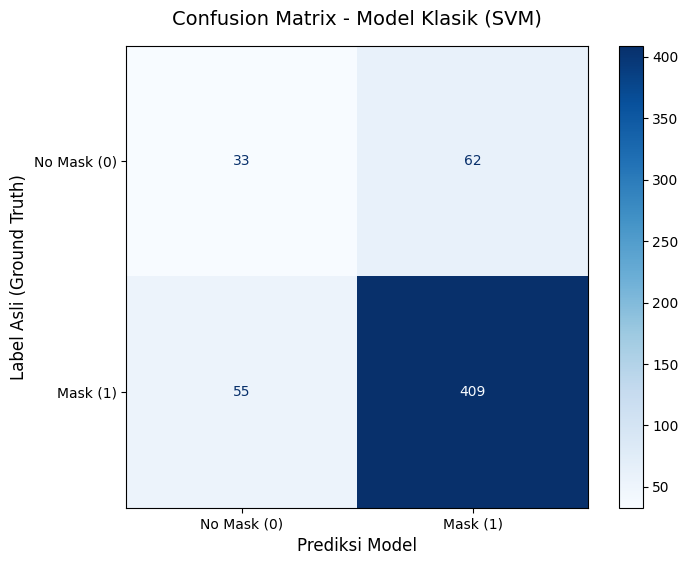

In [25]:
# MODEL SVM
y_pred_svm = svm_model.predict(X_test_hog)
plot_confusion_matrix(y_test, y_pred_svm, title="Confusion Matrix - Model Klasik (SVM)")


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


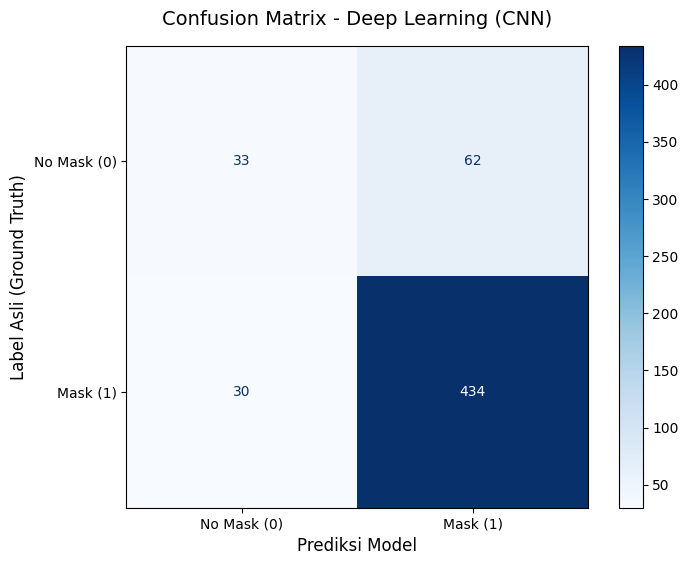

In [26]:
# MODEL CNN
y_pred_prob_cnn = cnn_model.predict(X_test)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int).flatten()
plot_confusion_matrix(y_test, y_pred_cnn, title="Confusion Matrix - Deep Learning (CNN)")

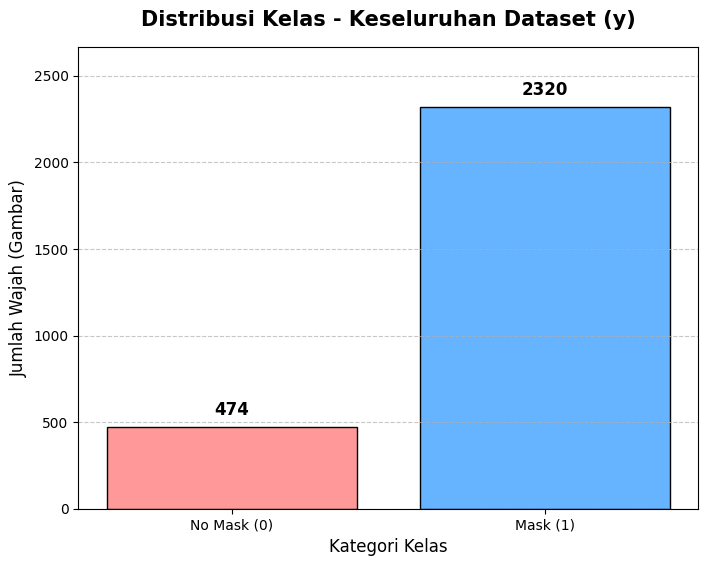

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(y_data, title="Distribusi Kelas pada Dataset"):
    """
    Fungsi untuk menampilkan bar chart dari distribusi kelas 0 dan 1.
    """
    # Menghitung jumlah unik masing-masing kelas
    unique_classes, counts = np.unique(y_data, return_counts=True)
    
    # Menentukan label string berdasarkan nilai unik yang ada di y_data
    labels = ['No Mask (0)' if cls == 0 else 'Mask (1)' for cls in unique_classes]
    
    # Membuat figure dan plot bar chart
    plt.figure(figsize=(8, 6))
    
    # Anda bisa mengganti warna bar sesuai selera (merah muda dan biru muda)
    bars = plt.bar(labels, counts, color=['#ff9999', '#66b3ff'], edgecolor='black')
    
    # Menambahkan teks angka persis di atas masing-masing batang (bar)
    for bar in bars:
        tinggi_bar = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, 
                 tinggi_bar + (max(counts) * 0.02), # Jarak teks dari puncak batang
                 f"{int(tinggi_bar)}", 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
                 
    # Mempercantik tampilan grafik
    plt.title(title, fontsize=15, fontweight='bold', pad=15)
    plt.ylabel('Jumlah Wajah (Gambar)', fontsize=12)
    plt.xlabel('Kategori Kelas', fontsize=12)
    
    # Memberi ruang ekstra di atas sumbu y agar angka tidak terpotong
    plt.ylim(0, max(counts) * 1.15) 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Menampilkan grafik di notebook
    plt.show()

# --- CARA PENGGUNAAN ---

# 1. Cek distribusi pada KESELURUHAN data (sebelum di-split)
plot_class_distribution(y, title="Distribusi Kelas - Keseluruhan Dataset (y)")

# 2. Cek distribusi pada DATA LATIH (setelah di-split)
# plot_class_distribution(y_train, title="Distribusi Kelas - Data Latih (y_train)")

# 3. Cek distribusi pada DATA UJI (setelah di-split)
# plot_class_distribution(y_test, title="Distribusi Kelas - Data Uji (y_test)")

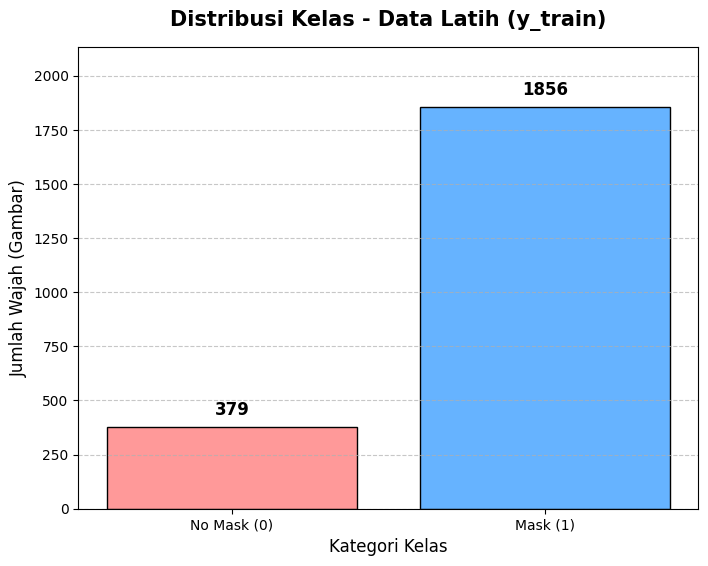

In [28]:
# 2. Cek distribusi pada DATA LATIH (setelah di-split)
plot_class_distribution(y_train, title="Distribusi Kelas - Data Latih (y_train)")


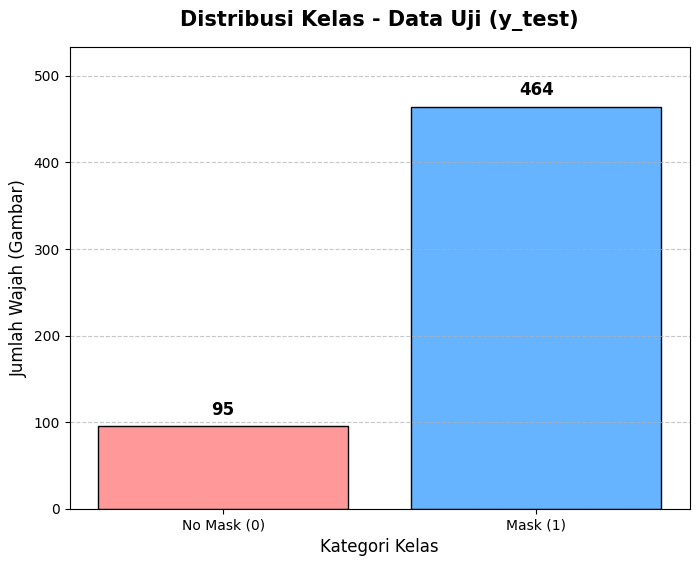

In [29]:
# 3. Cek distribusi pada DATA UJI (setelah di-split)
plot_class_distribution(y_test, title="Distribusi Kelas - Data Uji (y_test)")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


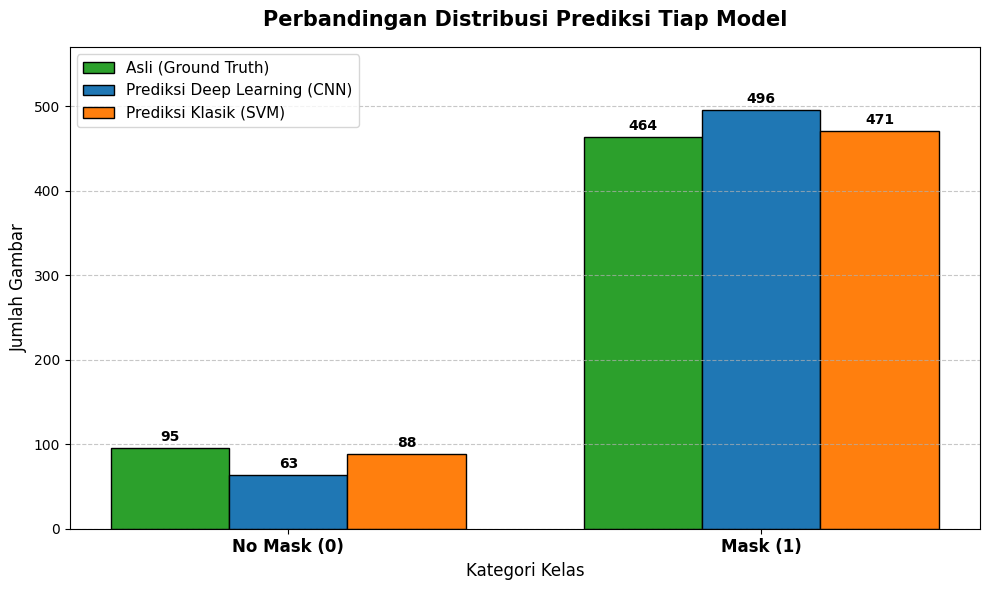

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_predictions_distribution(y_true, y_pred_cnn, y_pred_svm, title="Perbandingan Distribusi Prediksi Tiap Model"):
    """
    Menampilkan grouped bar chart untuk membandingkan distribusi kelas 
    asli (Ground Truth) dengan hasil tebakan model CNN dan SVM.
    """
    labels = ['No Mask (0)', 'Mask (1)']
    x = np.arange(len(labels))  # Lokasi label di sumbu x
    width = 0.25                # Lebar masing-masing batang

    # Fungsi bantuan untuk menghitung jumlah tiap kelas dengan aman
    def get_counts(y_array):
        # Memastikan y_array bertipe integer 1D
        y_array = np.array(y_array).flatten().astype(int)
        counts = [np.sum(y_array == 0), np.sum(y_array == 1)]
        return counts

    # Menghitung distribusi untuk masing-masing set
    counts_true = get_counts(y_true)
    counts_cnn = get_counts(y_pred_cnn)
    counts_svm = get_counts(y_pred_svm)

    # Membuat figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Membuat tiga set bar secara berdampingan
    rects1 = ax.bar(x - width, counts_true, width, label='Asli (Ground Truth)', color='#2ca02c', edgecolor='black')
    rects2 = ax.bar(x, counts_cnn, width, label='Prediksi Deep Learning (CNN)', color='#1f77b4', edgecolor='black')
    rects3 = ax.bar(x + width, counts_svm, width, label='Prediksi Klasik (SVM)', color='#ff7f0e', edgecolor='black')

    # Menambahkan detail teks, label, dan judul
    ax.set_ylabel('Jumlah Gambar', fontsize=12)
    ax.set_xlabel('Kategori Kelas', fontsize=12)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.legend(fontsize=11)

    # Fungsi untuk menempelkan angka persis di atas masing-masing bar
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{int(height)}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # Jarak 3 poin ke atas dari ujung bar
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Pasang label angka di ketiga bar
    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    # Mempercantik layout grafik
    fig.tight_layout()
    # Memberi ruang ekstra di atas agar angka tidak terpotong
    max_height = max(max(counts_true), max(counts_cnn), max(counts_svm))
    plt.ylim(0, max_height * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Tampilkan grafik
    plt.show()

# --- CARA PENGGUNAAN ---

# Pastikan variabel y_test, y_pred_cnn, dan y_pred_svm sudah tersedia di memori.
# (Biasanya diekstrak di tahap Evaluasi / Blok 6)
# 
y_pred_prob_cnn = cnn_model.predict(X_test)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int)
y_pred_svm = svm_model.predict(X_test_hog)

# Eksekusi visualisasi:
plot_model_predictions_distribution(y_test, y_pred_cnn, y_pred_svm)

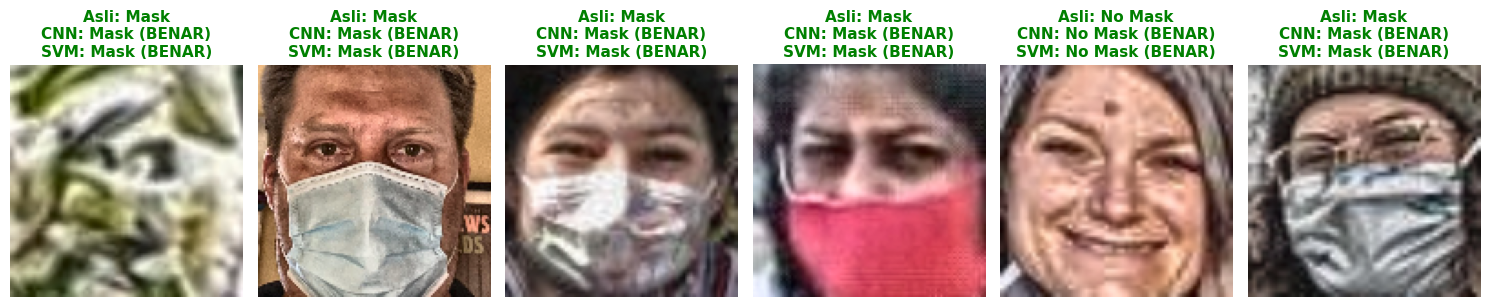

In [50]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_predictions(X_test_images, y_true, y_pred_cnn, y_pred_svm, num_samples=6):
    """
    Mengambil sampel acak dan menampilkan gambar beserta prediksi model 
    (Versi Perbaikan: Kompatibel dengan NumPy terbaru & Matplotlib Font).
    """
    if len(X_test_images) < num_samples:
        num_samples = len(X_test_images)
    indeks_acak = np.random.choice(len(X_test_images), num_samples, replace=False)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
    if num_samples == 1:
        axes = [axes]
        
    kamus_label = {0: "No Mask", 1: "Mask"}
    
    for i, idx in enumerate(indeks_acak):
        img = X_test_images[idx]
        
        # PERBAIKAN 1: Menggunakan .item() untuk mengekstrak angka skalar dari array
        # Jika struktur datanya bukan array numpy (seperti list biasa), gunakan nilai aslinya
        label_asli = int(y_true[idx].item() if hasattr(y_true[idx], 'item') else y_true[idx])
        pred_cnn = int(y_pred_cnn[idx].item() if hasattr(y_pred_cnn[idx], 'item') else y_pred_cnn[idx])
        pred_svm = int(y_pred_svm[idx].item() if hasattr(y_pred_svm[idx], 'item') else y_pred_svm[idx])
        
        axes[i].imshow(img)
        axes[i].axis('off')
        
        # PERBAIKAN 2: Mengganti Emoji dengan Teks Standar untuk menghindari Glyph Warning
        simbol_cnn = "(BENAR)" if pred_cnn == label_asli else "(SALAH)"
        simbol_svm = "(BENAR)" if pred_svm == label_asli else "(SALAH)"
        
        teks_judul = f"Asli: {kamus_label[label_asli]}\n"
        teks_judul += f"CNN: {kamus_label[pred_cnn]} {simbol_cnn}\n"
        teks_judul += f"SVM: {kamus_label[pred_svm]} {simbol_svm}"
        
        if pred_cnn == label_asli and pred_svm == label_asli:
            warna_teks = 'green'
        elif pred_cnn != label_asli and pred_svm != label_asli:
            warna_teks = 'red'
        else:
            warna_teks = 'darkorange'
            
        axes[i].set_title(teks_judul, fontsize=11, color=warna_teks, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# --- CARA PENGGUNAAN ---
# Eksekusi visualisasi:
visualize_random_predictions(X_test, y_test, y_pred_cnn, y_pred_svm, num_samples=6)